In [1]:
# Import required libraries

import pandas as pd
import numpy as np

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning libraries
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Date and time
from datetime import datetime

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

In [3]:
import pandas as pd

df = pd.read_csv("Customer_Behavior.csv", encoding='latin1')

print(df.head())
print("Shape:", df.shape)
print(df.dtypes)
print(df.isnull().sum())

   Customer ID        Purchase Date Product Category  Product Price  Quantity  \
0        46251  2020-09-08 09:38:32      Electronics             12         3   
1        46251  2022-03-05 12:56:35             Home            468         4   
2        46251  2022-05-23 18:18:01             Home            288         2   
3        46251  2020-11-12 13:13:29         Clothing            196         1   
4        13593  2020-11-27 17:55:11             Home            449         1   

   Total Purchase Amount Payment Method  Customer Age  Returns  \
0                    740    Credit Card            37      0.0   
1                   2739         PayPal            37      0.0   
2                   3196         PayPal            37      0.0   
3                   3509         PayPal            37      0.0   
4                   3452    Credit Card            49      0.0   

         Customer Name  Age  Gender  Churn  
0  Christine Hernandez   37    Male      0  
1  Christine Hernandez   3

In [4]:
customer_orders = df.groupby('Customer ID')[
      'Customer ID'
].count()

returning_customers = customer_orders[
       customer_orders > 1
].count()

total_customers = df['Customer ID'].nunique()

retention_rate = (
       returning_customers / total_customers
) * 100

print("Retention Rate:", retention_rate)

Retention Rate: 96.60781511082479


In [5]:
revenue_per_customer = (
      df['Total Purchase Amount'].sum()
          / df['Customer ID'].nunique()
)

print("Average Revenue Per Customer:", revenue_per_customer)

Average Revenue Per Customer: 13716.559962152478


In [6]:
active_customers = df.groupby('Customer ID').size()

top_active = active_customers.sort_values(
    ascending=False
    ).head(10)

print(top_active)

Customer ID
47087    17
39817    17
36437    17
809      15
35424    15
6426     15
14400    15
5252     15
28852    15
12529    15
dtype: int64


In [8]:
import pandas as pd

# Convert date column
df['Purchase Date'] = pd.to_datetime(
    df['Purchase Date']
    )

    # Create reference date
reference_date = (
        df['Purchase Date'].max()
            + pd.Timedelta(days=1)
            )

            # Create RFM table
rfm = df.groupby('Customer ID').agg({
                'Purchase Date': lambda x:
                        (reference_date - x.max()).days,

                            'Customer ID': 'count',

                                'Total Purchase Amount': 'sum',

                                    'Churn': 'max'
                                    })

                                    # Rename columns
rfm.columns = [
                                        'Recency',
                                            'Frequency',
                                                'Monetary',
                                                    'Churn'
                                                    ]

print(rfm.head())

             Recency  Frequency  Monetary  Churn
Customer ID                                     
1                 58          1      3491      0
2                299          3      7988      0
3                 89          8     22587      0
4                127          4      8715      1
5                171          8     12524      0


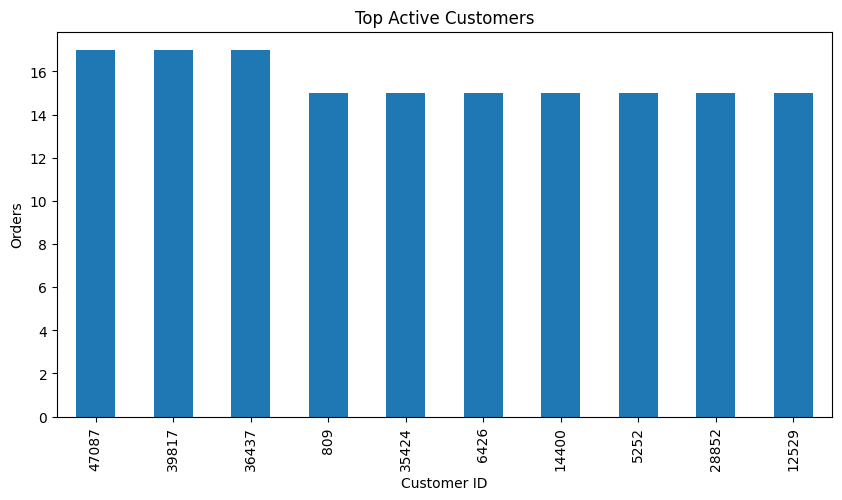

In [7]:
import matplotlib.pyplot as plt

top_active.plot(
    kind='bar',
        figsize=(10,5)
        )

plt.title("Top Active Customers")

plt.ylabel("Orders")

plt.show()

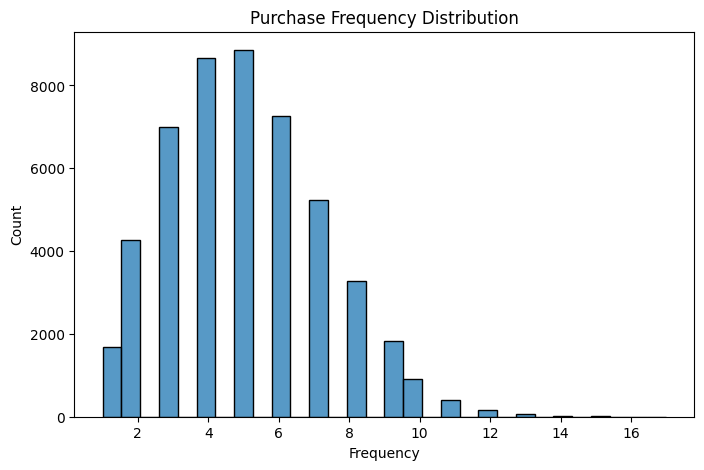

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

sns.histplot(
    rfm['Frequency'],
        bins=30
        )

plt.title("Purchase Frequency Distribution")

plt.show()

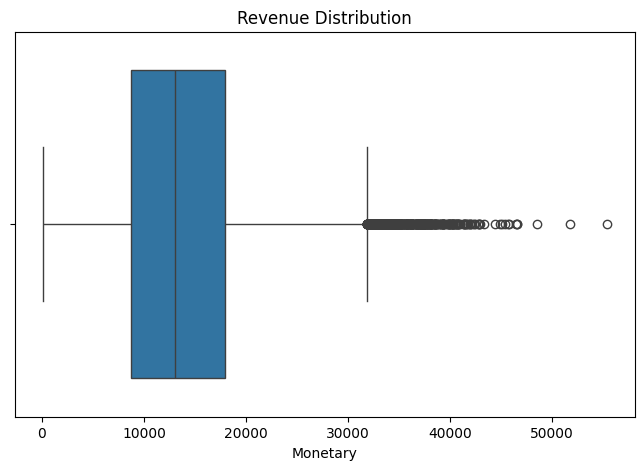

In [10]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x=rfm['Monetary']
    )

plt.title("Revenue Distribution")

plt.show()

In [11]:
high_spenders = rfm[
      rfm['Monetary'] >
          rfm['Monetary'].quantile(0.90)
          ]

print(high_spenders.head())

             Recency  Frequency  Monetary  Churn
Customer ID                                     
11               137         10     23691      0
17                14          9     24042      0
18               116          8     23726      0
22                21          9     32052      0
24               142          6     23966      1


In [12]:
low_engagement = rfm[
      (rfm['Frequency'] < 2) &
          (rfm['Recency'] > 100)
          ]

print(low_engagement.head())

             Recency  Frequency  Monetary  Churn
Customer ID                                     
221              530          1      1682      0
222             1166          1      1858      0
228             1344          1      4391      0
259              555          1      1567      1
278              154          1       497      0


In [13]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import MiniBatchKMeans

# Scale features
scaler = StandardScaler()

scaled_features = scaler.fit_transform(
    rfm[['Recency', 'Frequency', 'Monetary']]
    )

    # Clustering
kmeans = MiniBatchKMeans(
        n_clusters=4,
            random_state=42
            )

rfm['Cluster'] = kmeans.fit_predict(
                scaled_features
                )

In [14]:
segment_map = {
      0: 'Loyal Customers',
          1: 'At Risk',
              2: 'High Value',
                  3: 'Regular Customers'
                  }

rfm['Segment'] = rfm['Cluster'].map(
                      segment_map
                      )

In [15]:
print(rfm.columns)

Index(['Recency', 'Frequency', 'Monetary', 'Churn', 'Cluster', 'Segment'], dtype='object')


In [16]:
segment_contribution = (
      rfm.groupby('Segment')['Monetary']
          .sum()
          )

print(segment_contribution)

Segment
At Risk               91665415
High Value           283421759
Loyal Customers      253161555
Regular Customers     53093954
Name: Monetary, dtype: int64


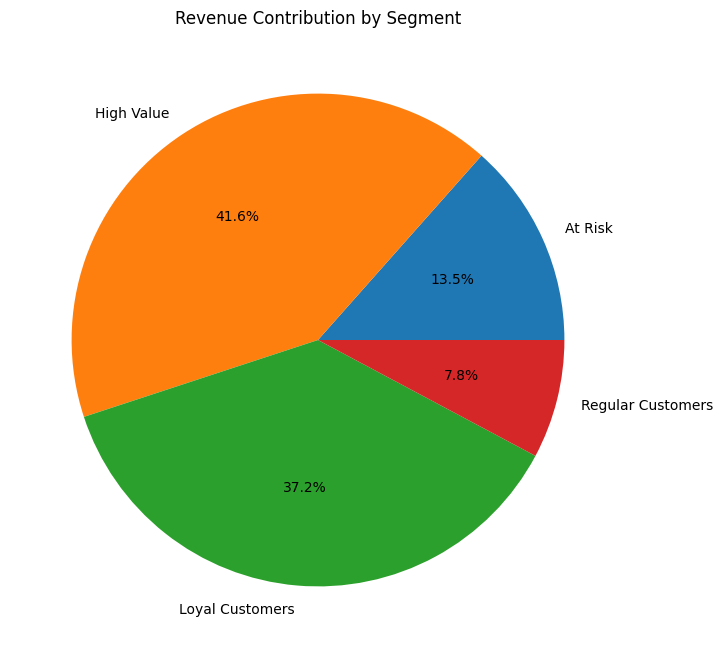

In [17]:
import matplotlib.pyplot as plt

segment_contribution.plot(
    kind='pie',
        autopct='%1.1f%%',
            figsize=(8,8)
            )

plt.title("Revenue Contribution by Segment")

plt.ylabel("")

plt.show()

In [18]:
daily_sales = df.groupby(
      'Purchase Date'
      )['Total Purchase Amount'].sum()

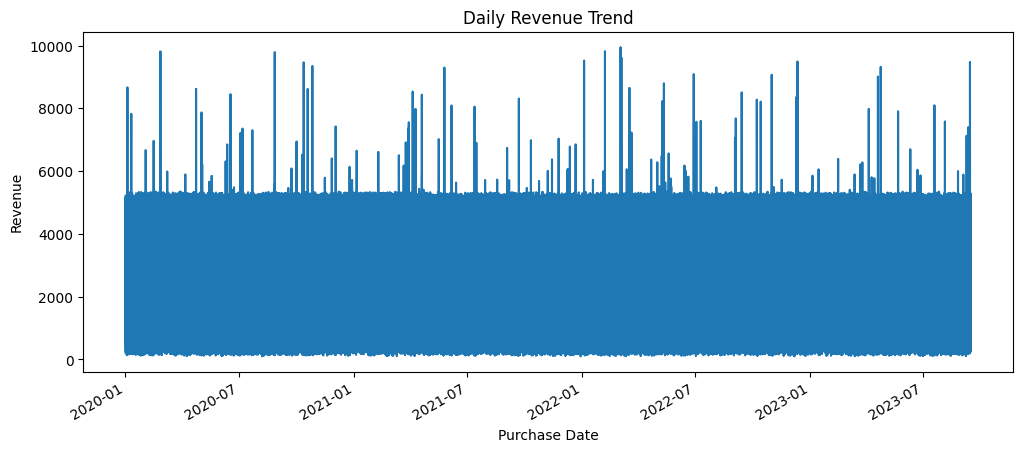

In [19]:
daily_sales.plot(
      figsize=(12,5)
      )

plt.title("Daily Revenue Trend")

plt.ylabel("Revenue")

plt.show()


In [20]:
rolling_sales = daily_sales.rolling(
      window=7
      ).mean()


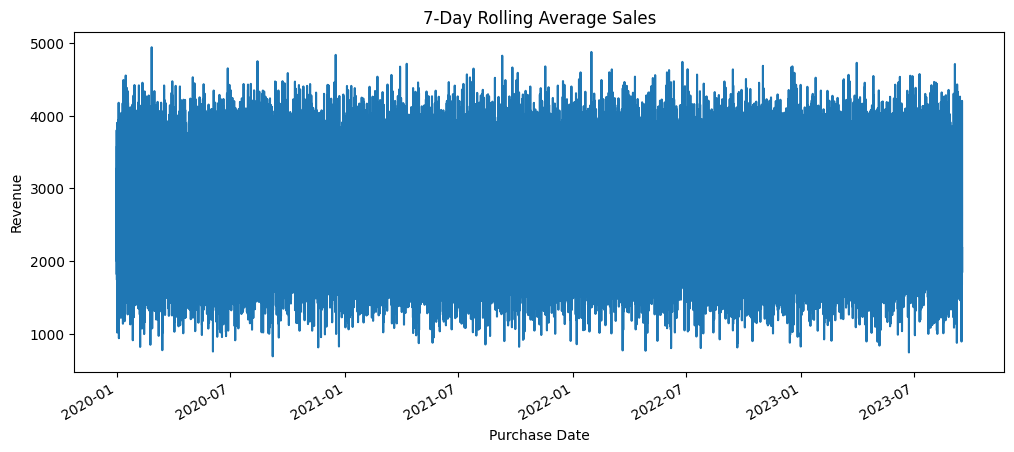

In [21]:
rolling_sales.plot(
      figsize=(12,5)
      )

plt.title("7-Day Rolling Average Sales")

plt.ylabel("Revenue")

plt.show()


In [22]:
correlation = rfm[
      ['Recency', 'Frequency', 'Monetary']
      ].corr()

print(correlation)

            Recency  Frequency  Monetary
Recency    1.000000  -0.412583 -0.363966
Frequency -0.412583   1.000000  0.878992
Monetary  -0.363966   0.878992  1.000000


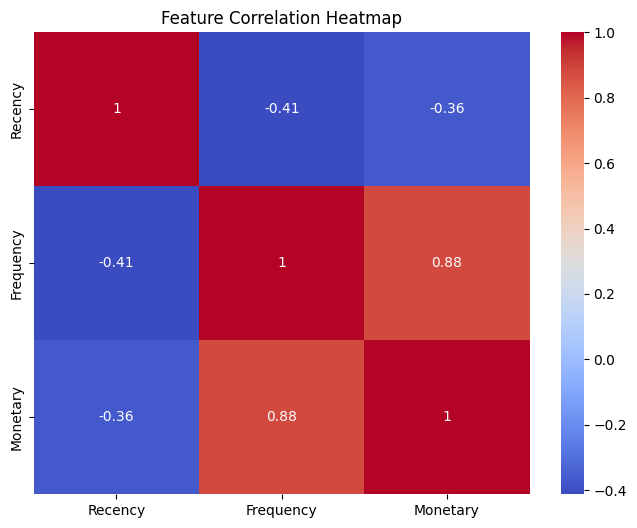

In [23]:
plt.figure(figsize=(8,6))

sns.heatmap(
    correlation,
        annot=True,
            cmap='coolwarm'
            )

plt.title("Feature Correlation Heatmap")

plt.show()

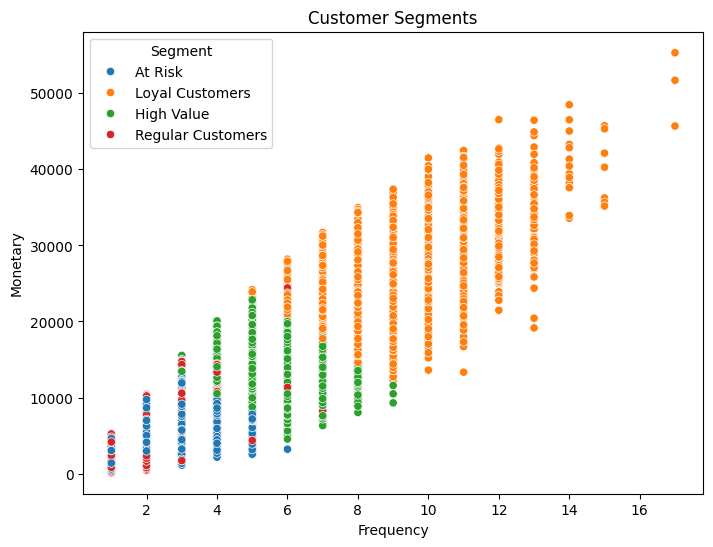

In [24]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x='Frequency',
        y='Monetary',
            hue='Segment',
                data=rfm
                )

plt.title("Customer Segments")

plt.show()

In [25]:
rfm['Churn Risk Score'] = (
      rfm['Recency']
          /
              (rfm['Frequency'] + 1)
              )

print(rfm.head())


             Recency  Frequency  Monetary  Churn  Cluster          Segment  \
Customer ID                                                                  
1                 58          1      3491      0        1          At Risk   
2                299          3      7988      0        1          At Risk   
3                 89          8     22587      0        0  Loyal Customers   
4                127          4      8715      1        1          At Risk   
5                171          8     12524      0        2       High Value   

             Churn Risk Score  
Customer ID                    
1                   29.000000  
2                   74.750000  
3                    9.888889  
4                   25.400000  
5                   19.000000  


In [26]:
high_churn_risk = rfm[
      rfm['Churn Risk Score'] >
          rfm['Churn Risk Score'].quantile(0.90)
          ]

print(high_churn_risk.head())

             Recency  Frequency  Monetary  Churn  Cluster            Segment  \
Customer ID                                                                    
34               972          2      3345      0        3  Regular Customers   
40               479          2      5188      0        1            At Risk   
52               449          2      5280      0        1            At Risk   
63               702          2      1630      0        3  Regular Customers   
80               889          3      3614      1        3  Regular Customers   

             Churn Risk Score  
Customer ID                    
34                 324.000000  
40                 159.666667  
52                 149.666667  
63                 234.000000  
80                 222.250000  


In [27]:
dashboard = {
      "Total Revenue":
          df['Total Purchase Amount'].sum(),

              "Total Customers":
                  df['Customer ID'].nunique(),

                      "Average Order Value":
                          df['Total Purchase Amount'].mean(),

                              "Retention Rate":
                                  retention_rate
                                  }

print(dashboard)

{'Total Revenue': np.int64(681342683), 'Total Customers': 49673, 'Average Order Value': np.float64(2725.370732), 'Retention Rate': np.float64(96.60781511082479)}
